# Analisis y Prediccion de Shock Hemorragico

Este notebook demuestra el uso del pipeline de prediccion de shock hemorragico.

## Contenido
1. Configuracion inicial
2. Carga y exploracion de datos
3. Preprocesamiento
4. Entrenamiento de modelos
5. Evaluacion y seleccion
6. Calibracion y optimizacion de umbral
7. Interpretabilidad
8. Resultados finales

## 1. Configuracion Inicial

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Agregar directorio raiz al path
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Configuracion completada")

Configuracion completada


## 2. Carga y Exploracion de Datos

In [2]:
# Ruta al archivo de datos
DATA_PATH = "../data/processed/shock.csv"

# Cargar datos
df = pd.read_csv(DATA_PATH)
print(f"Datos cargados: {df.shape[0]} filas x {df.shape[1]} columnas")

# Primeras filas
df.head()

Datos cargados: 1324 filas x 22 columnas


,CODIGO,EDAD,GENERO,ACT_FISICA_METS,HB_PREQX,SHOCK,MUERTE.1,HIPERTENSION,DIABETES,ENFERMEDAD_CORONARIA,...,ERC,INMUNOSUPRESION,OBESIDAD,HIPERTENSION_PULMONAR,EPOC,ASMA,ENF_CEREBROVASCULAR,CANCER_ACTIVO,TABAQUISMO,SANGRADO_MAYOR
0,2,56.0,0.0,0.0,14.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,29.0,1.0,0.0,17.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,59.0,1.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,72.0,0.0,0.0,14.6,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6,75.0,0.0,0.0,13.3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Informacion general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CODIGO                 1324 non-null   int64  
 1   EDAD                   1324 non-null   float64
 2   GENERO                 1324 non-null   float64
 3   ACT_FISICA_METS        1324 non-null   float64
 4   HB_PREQX               1324 non-null   float64
 5   SHOCK                  1324 non-null   float64
 6   MUERTE.1               1324 non-null   float64
 7   HIPERTENSION           1324 non-null   float64
 8   DIABETES               1324 non-null   float64
 9   ENFERMEDAD_CORONARIA   1324 non-null   float64
 10  FALLA_CARDIACA         1324 non-null   float64
 11  HIPOTIROIDISMO         1324 non-null   float64
 12  ERC                    1324 non-null   float64
 13  INMUNOSUPRESION        1324 non-null   float64
 14  OBESIDAD               1324 non-null   float64
 15  HIPE

Columna objetivo: SHOCK

Distribucion de clases:
SHOCK
0.0    897
1.0    427
Name: count, dtype: int64


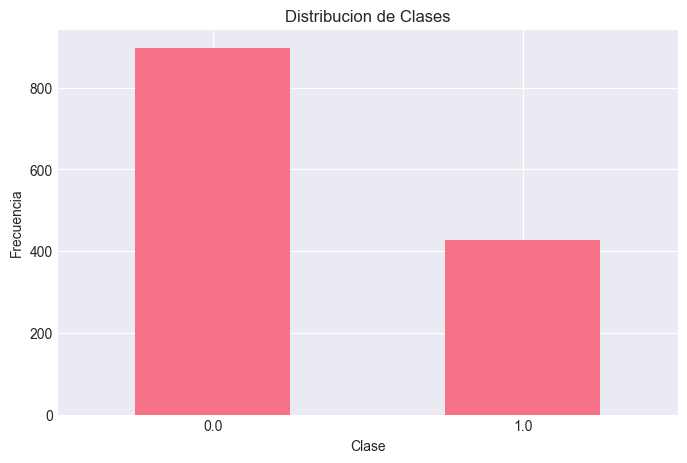

In [4]:
# Detectar columna objetivo
target_col = next((c for c in df.columns if 'shock' in c.lower()), None)
print(f"Columna objetivo: {target_col}")

# Distribucion de clases
if target_col:
    print("\nDistribucion de clases:")
    print(df[target_col].value_counts())
    
    # Visualizar
    plt.figure(figsize=(8, 5))
    df[target_col].value_counts().plot(kind='bar')
    plt.title('Distribucion de Clases')
    plt.xlabel('Clase')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=0)
    plt.show()

In [5]:
# Valores faltantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print("Valores faltantes por columna:")
    print(missing)
    
    # Visualizar top 20
    plt.figure(figsize=(10, 6))
    missing.head(20).plot(kind='barh')
    plt.title('Top 20 Columnas con Valores Faltantes')
    plt.xlabel('Numero de Valores Faltantes')
    plt.show()
else:
    print("No hay valores faltantes")

No hay valores faltantes


## 3. Pipeline Completo

Ejecutamos el pipeline completo de entrenamiento y evaluacion.

In [6]:
from src.pipelines.shock_pipeline import ShockPredictionPipeline

# Configuracion
OUTPUT_DIR = "../reports/shock_output"
SEED = 42

# Crear pipeline
pipeline = ShockPredictionPipeline(
    data_path=DATA_PATH,
    output_dir=OUTPUT_DIR,
    seed=SEED
)

print("Pipeline creado")

Pipeline creado


### 3.1 Carga y Limpieza

In [7]:
# Cargar y limpiar datos
X, y = pipeline.load_and_clean_data()


CARGA Y LIMPIEZA DE DATOS
Datos cargados: 1324 filas x 22 columnas
Columna objetivo detectada: SHOCK
Variables postoperatorias excluidas (2): ['MUERTE.1', 'SANGRADO_MAYOR']
Features preparados: 18 columnas
Distribucion del target: {0: 897, 1: 427}
Estadisticas descriptivas guardadas en: ../reports/shock_output/continuous_describe.csv


### 3.2 Division Train/Test

In [8]:
# Dividir datos
pipeline.split_data(X, y, test_size=0.20)


DIVISION TRAIN/TEST
Train: (1059, 18)
Test: (265, 18)
Distribucion train: {0: 717, 1: 342}
Distribucion test: {0: 180, 1: 85}


### 3.3 Construccion del Preprocesador

In [9]:
# Construir preprocesador
preprocessor = pipeline.build_preprocessor()


CONSTRUCCION DEL PREPROCESADOR
Columnas numericas: 3
Columnas categoricas/binarias: 15
Grafico de distribuciones guardado en: ../reports/shock_output/numeric_distributions.png


## 4. Entrenamiento de Modelos

In [10]:
# Entrenar modelos con GridSearchCV
fitted_grids = pipeline.train_models(cv_splits=5)


ENTRENAMIENTO DE MODELOS

Entrenando logreg...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejores parametros: {'clf__C': 0.1, 'clf__penalty': 'l1'}
Mejor CV recall: 0.5993

Entrenando rf...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parametros: {'clf__max_depth': 4, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Mejor CV recall: 0.4333


## 5. Evaluacion en Test

In [11]:
# Evaluar modelos
evals = pipeline.evaluate_models()


EVALUACION EN TEST

logreg - Test Metrics:
  Recall: 0.7294
  Precision: 0.3827
  AUC: 0.6150
  Specificity: 0.4444
  Confusion Matrix: TN=80, FP=100, FN=23, TP=62

rf - Test Metrics:
  Recall: 0.6000
  Precision: 0.3778
  AUC: 0.6002
  Specificity: 0.5333
  Confusion Matrix: TN=96, FP=84, FN=34, TP=51

Resumen guardado en: ../reports/shock_output/model_summary.json


In [12]:
# Comparar modelos
summary = pipeline.evaluator.get_summary()
summary_df = pd.DataFrame(summary).T
summary_df

,recall,precision,auc,specificity,best_params
logreg,0.729412,0.382716,0.614967,0.444444,"{'clf__C': 0.1, 'clf__penalty': 'l1'}"
rf,0.6,0.377778,0.600229,0.533333,"{'clf__max_depth': 4, 'clf__min_samples_leaf':..."


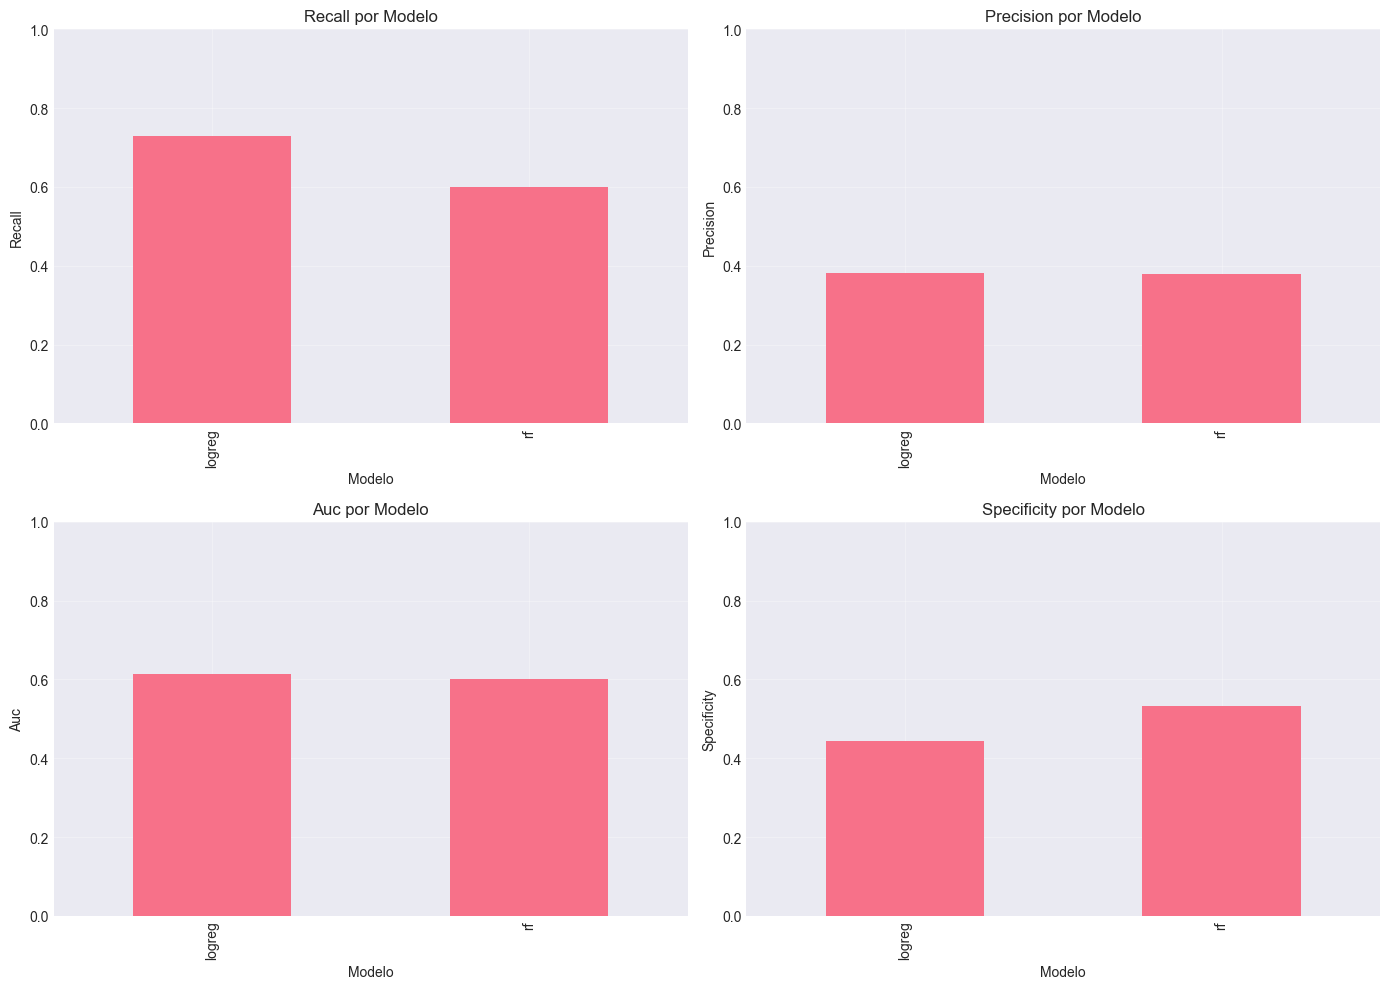

In [13]:
# Visualizar comparacion de metricas
metrics = ['recall', 'precision', 'auc', 'specificity']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    summary_df[metric].plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{metric.capitalize()} por Modelo')
    axes[i].set_ylabel(metric.capitalize())
    axes[i].set_xlabel('Modelo')
    axes[i].set_ylim([0, 1])
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Calibracion y Optimizacion de Umbral

In [14]:
# Seleccionar y calibrar mejor modelo
proba_calibrated = pipeline.select_and_calibrate_best_model()


SELECCION Y CALIBRACION DEL MEJOR MODELO

Mejor modelo seleccionado: logreg

logreg - Calibrated Metrics:
  Recall: 0.0941
  Precision: 0.4444
  AUC: 0.6031
  Specificity: 0.9444


In [15]:
# Optimizar umbral
tuned_threshold = pipeline.tune_threshold(proba_calibrated, min_spec=0.6)


OPTIMIZACION DE UMBRAL

Umbral optimizado: 0.4103
  Recall: 0.1882
  Specificity: 0.8444
  Precision: 0.3636

Recall en umbral 0.410: 0.188
95% CI: [0.108, 0.271]


## 7. Visualizaciones

In [16]:
# Generar todas las visualizaciones
pipeline.generate_visualizations()


GENERACION DE VISUALIZACIONES
Curva ROC guardada en: ../reports/shock_output/roc_curve.png
Curva Precision-Recall guardada en: ../reports/shock_output/precision_recall_curve.png
Matriz de confusion guardada en: ../reports/shock_output/confusion_matrix.png
Curva de calibracion guardada en: ../reports/shock_output/calibration_curve.png
Analisis de umbrales guardado en: ../reports/shock_output/threshold_analysis.png



roc_curve.png


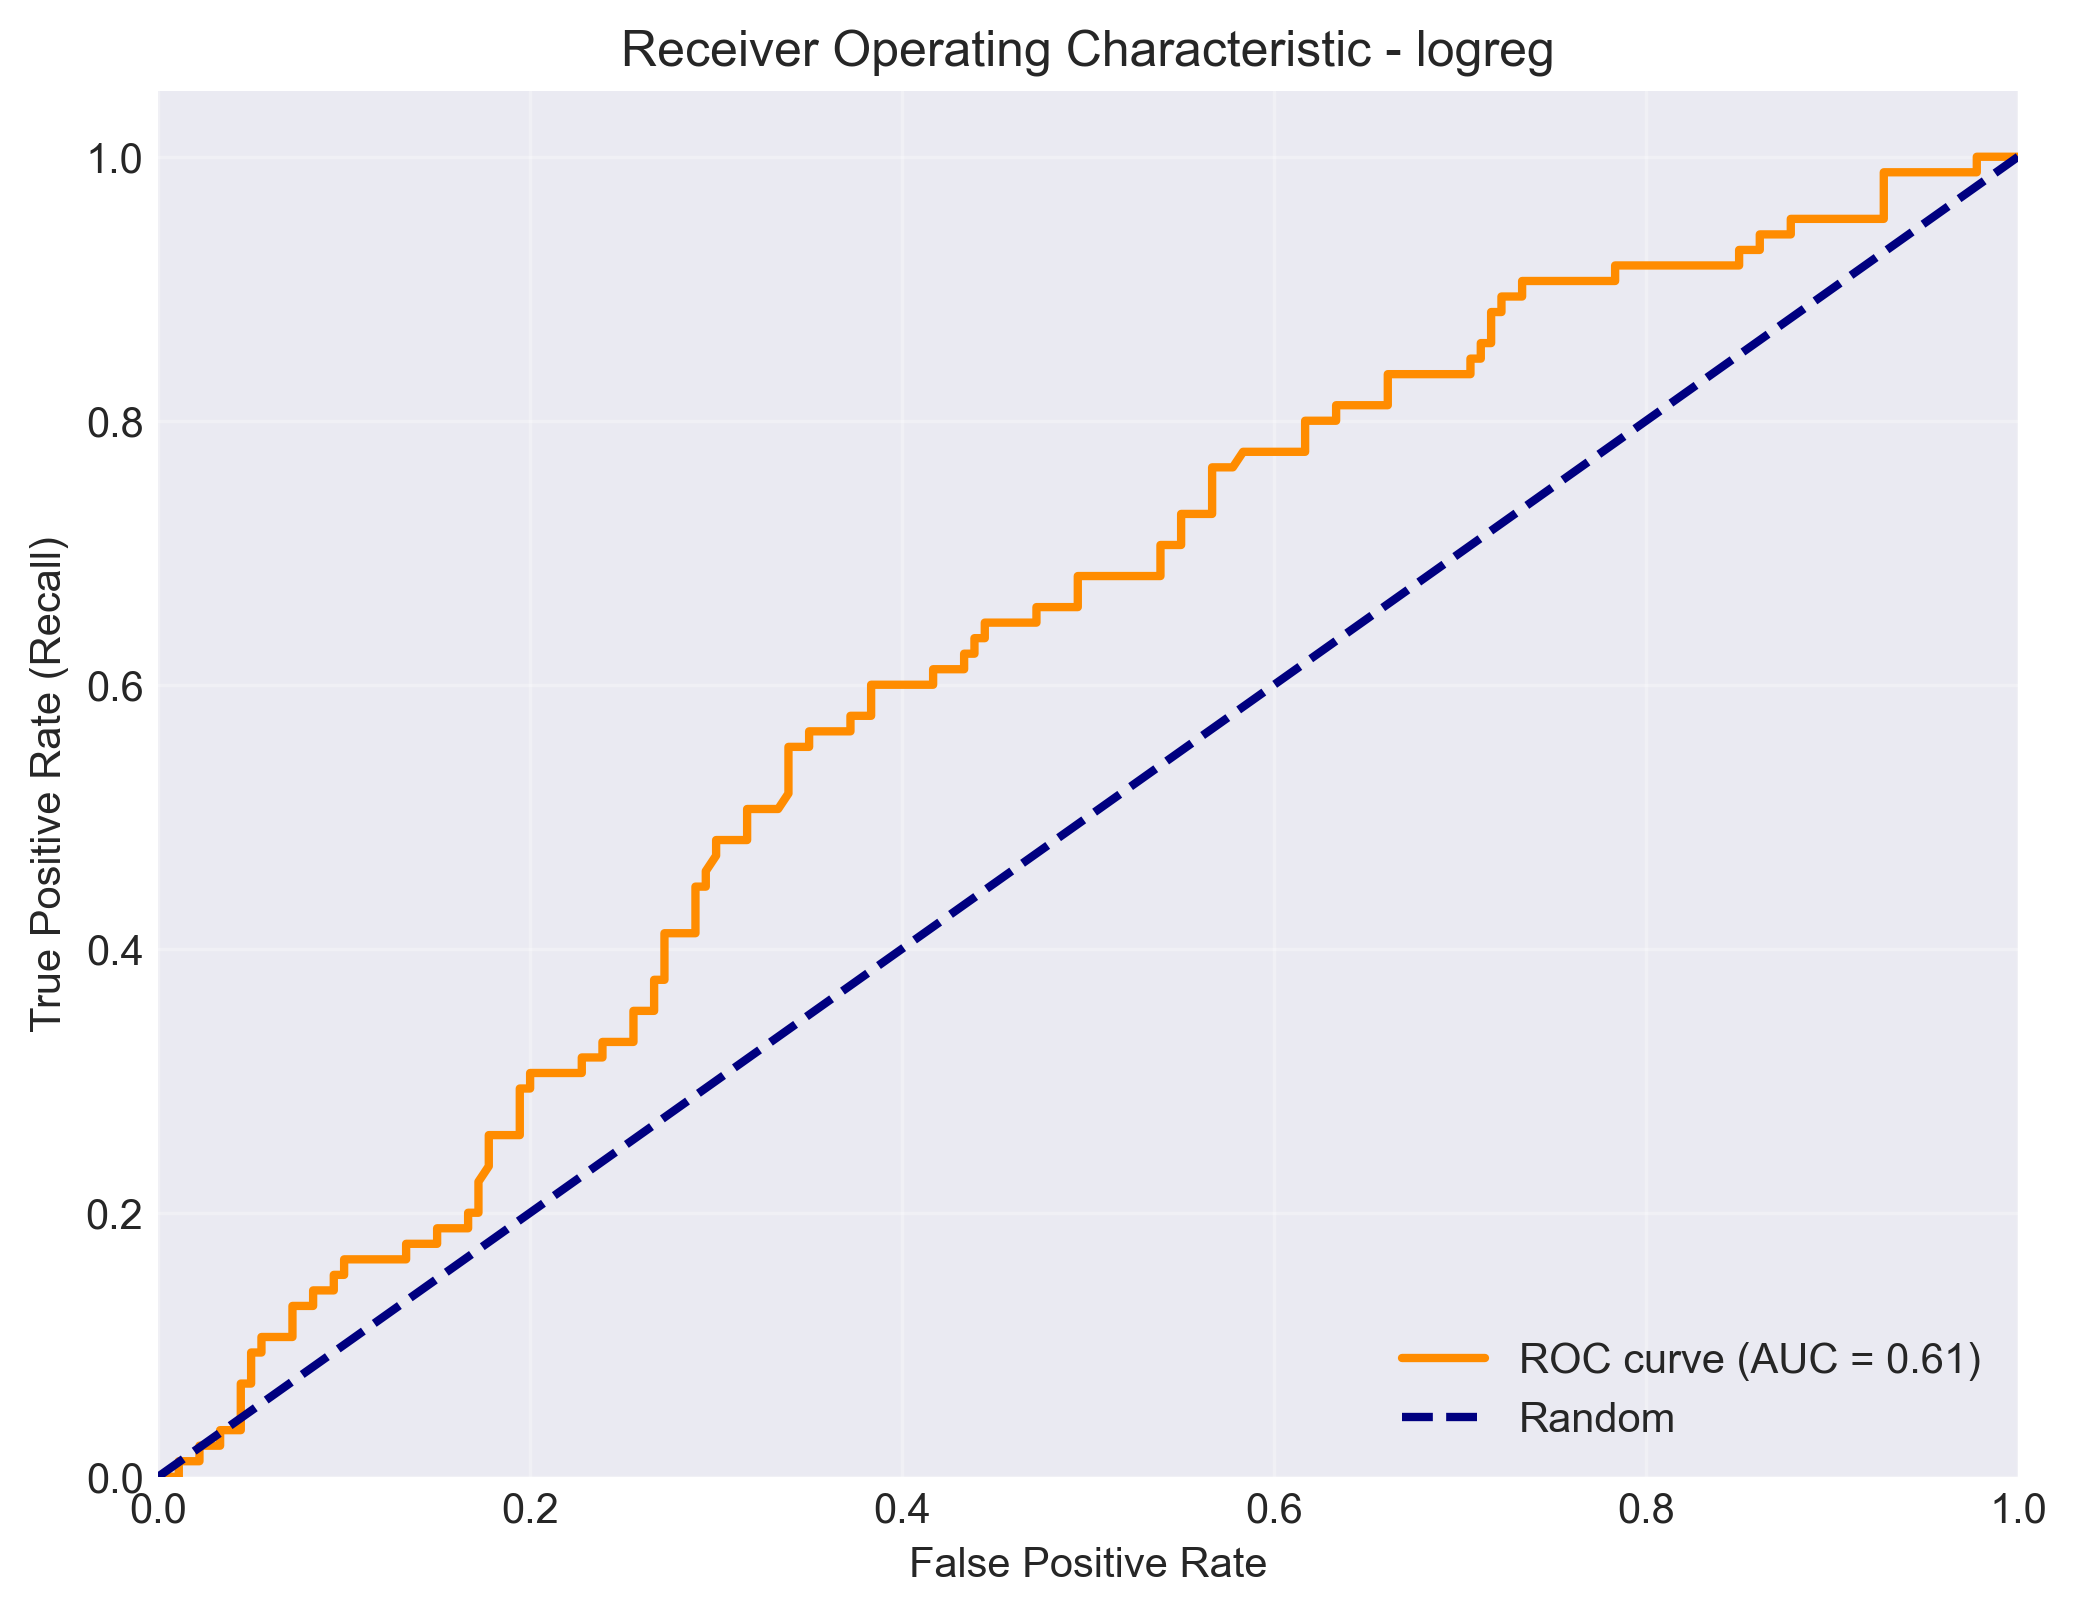


precision_recall_curve.png


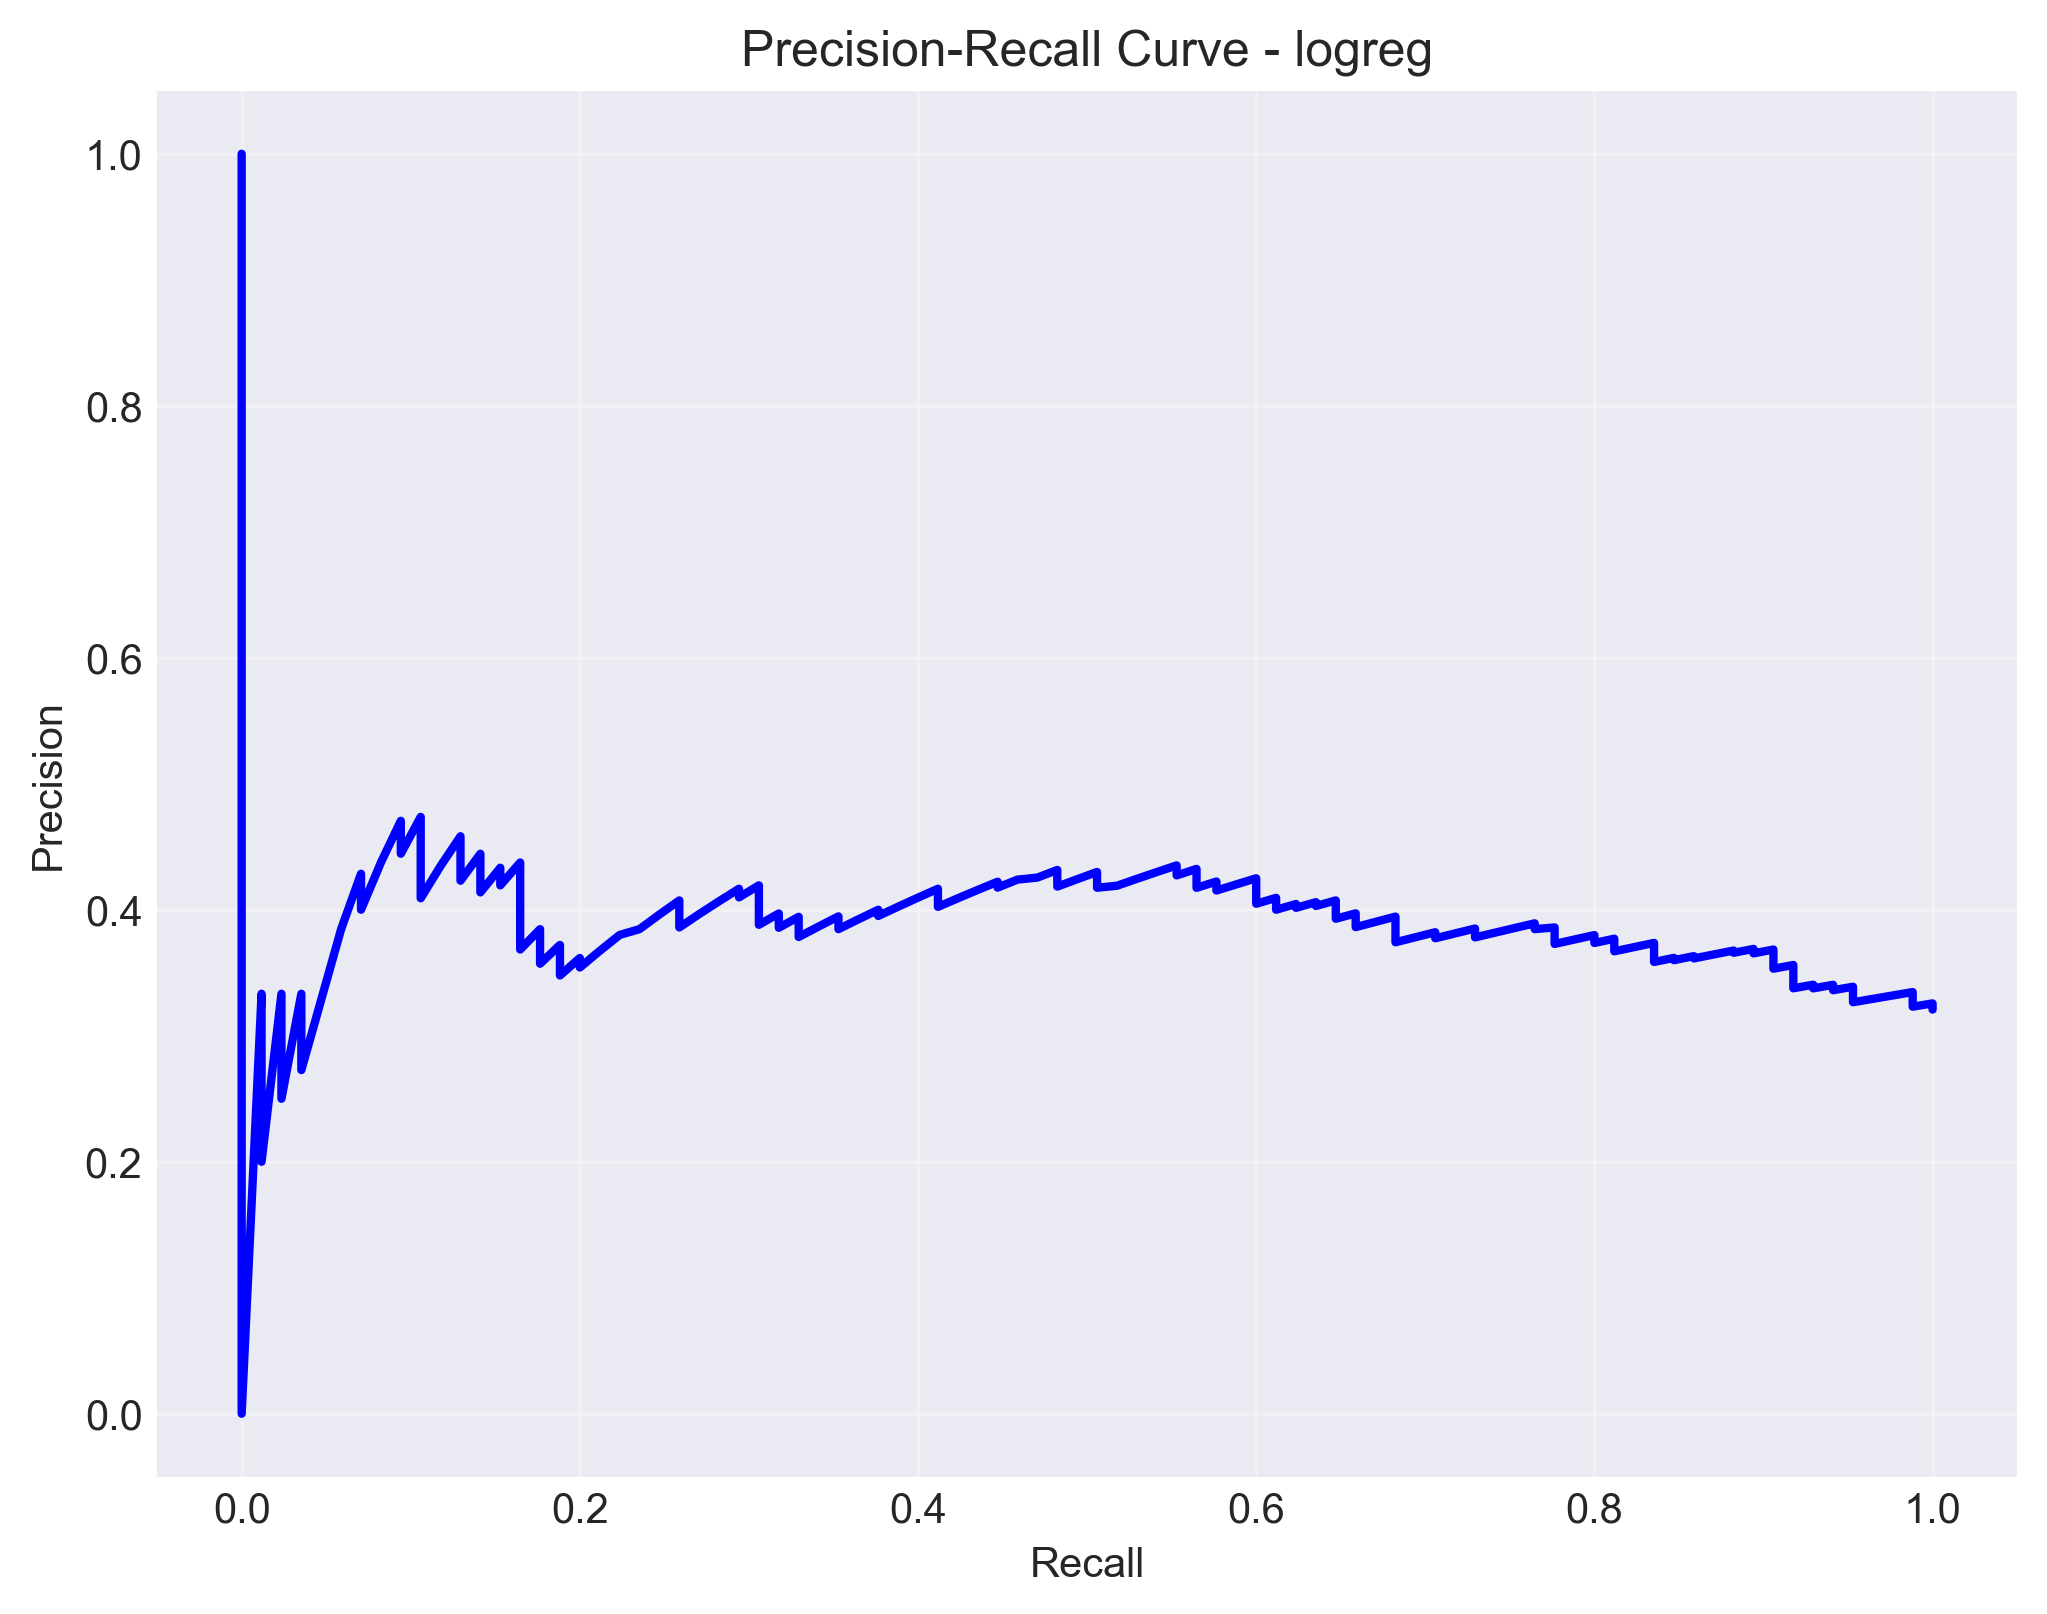


confusion_matrix.png


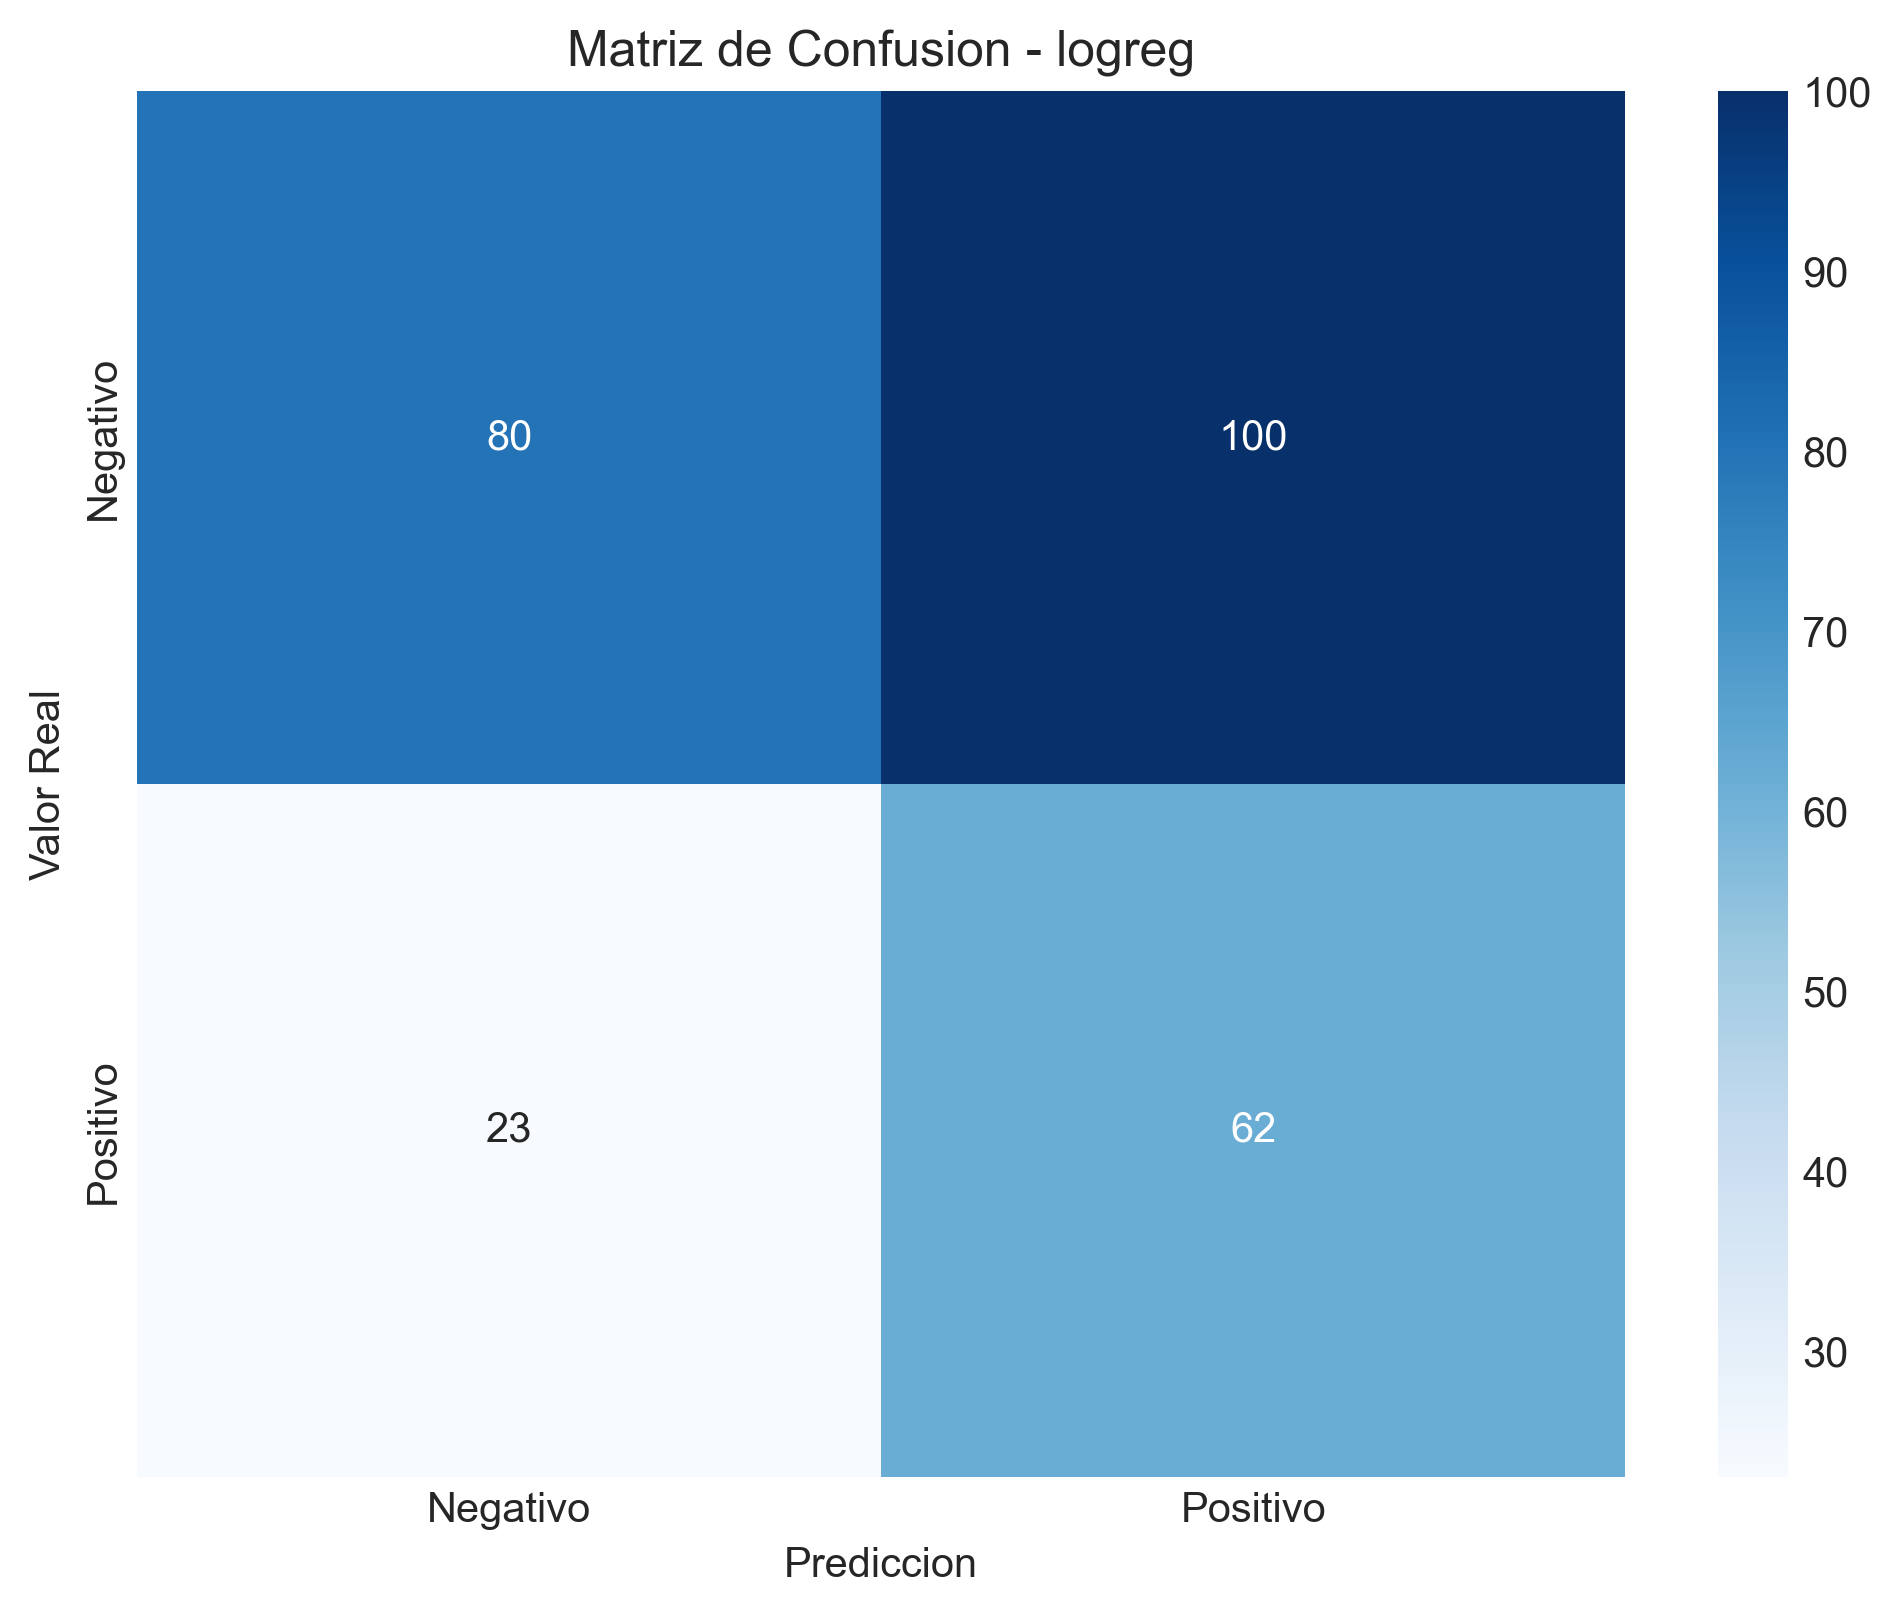


calibration_curve.png


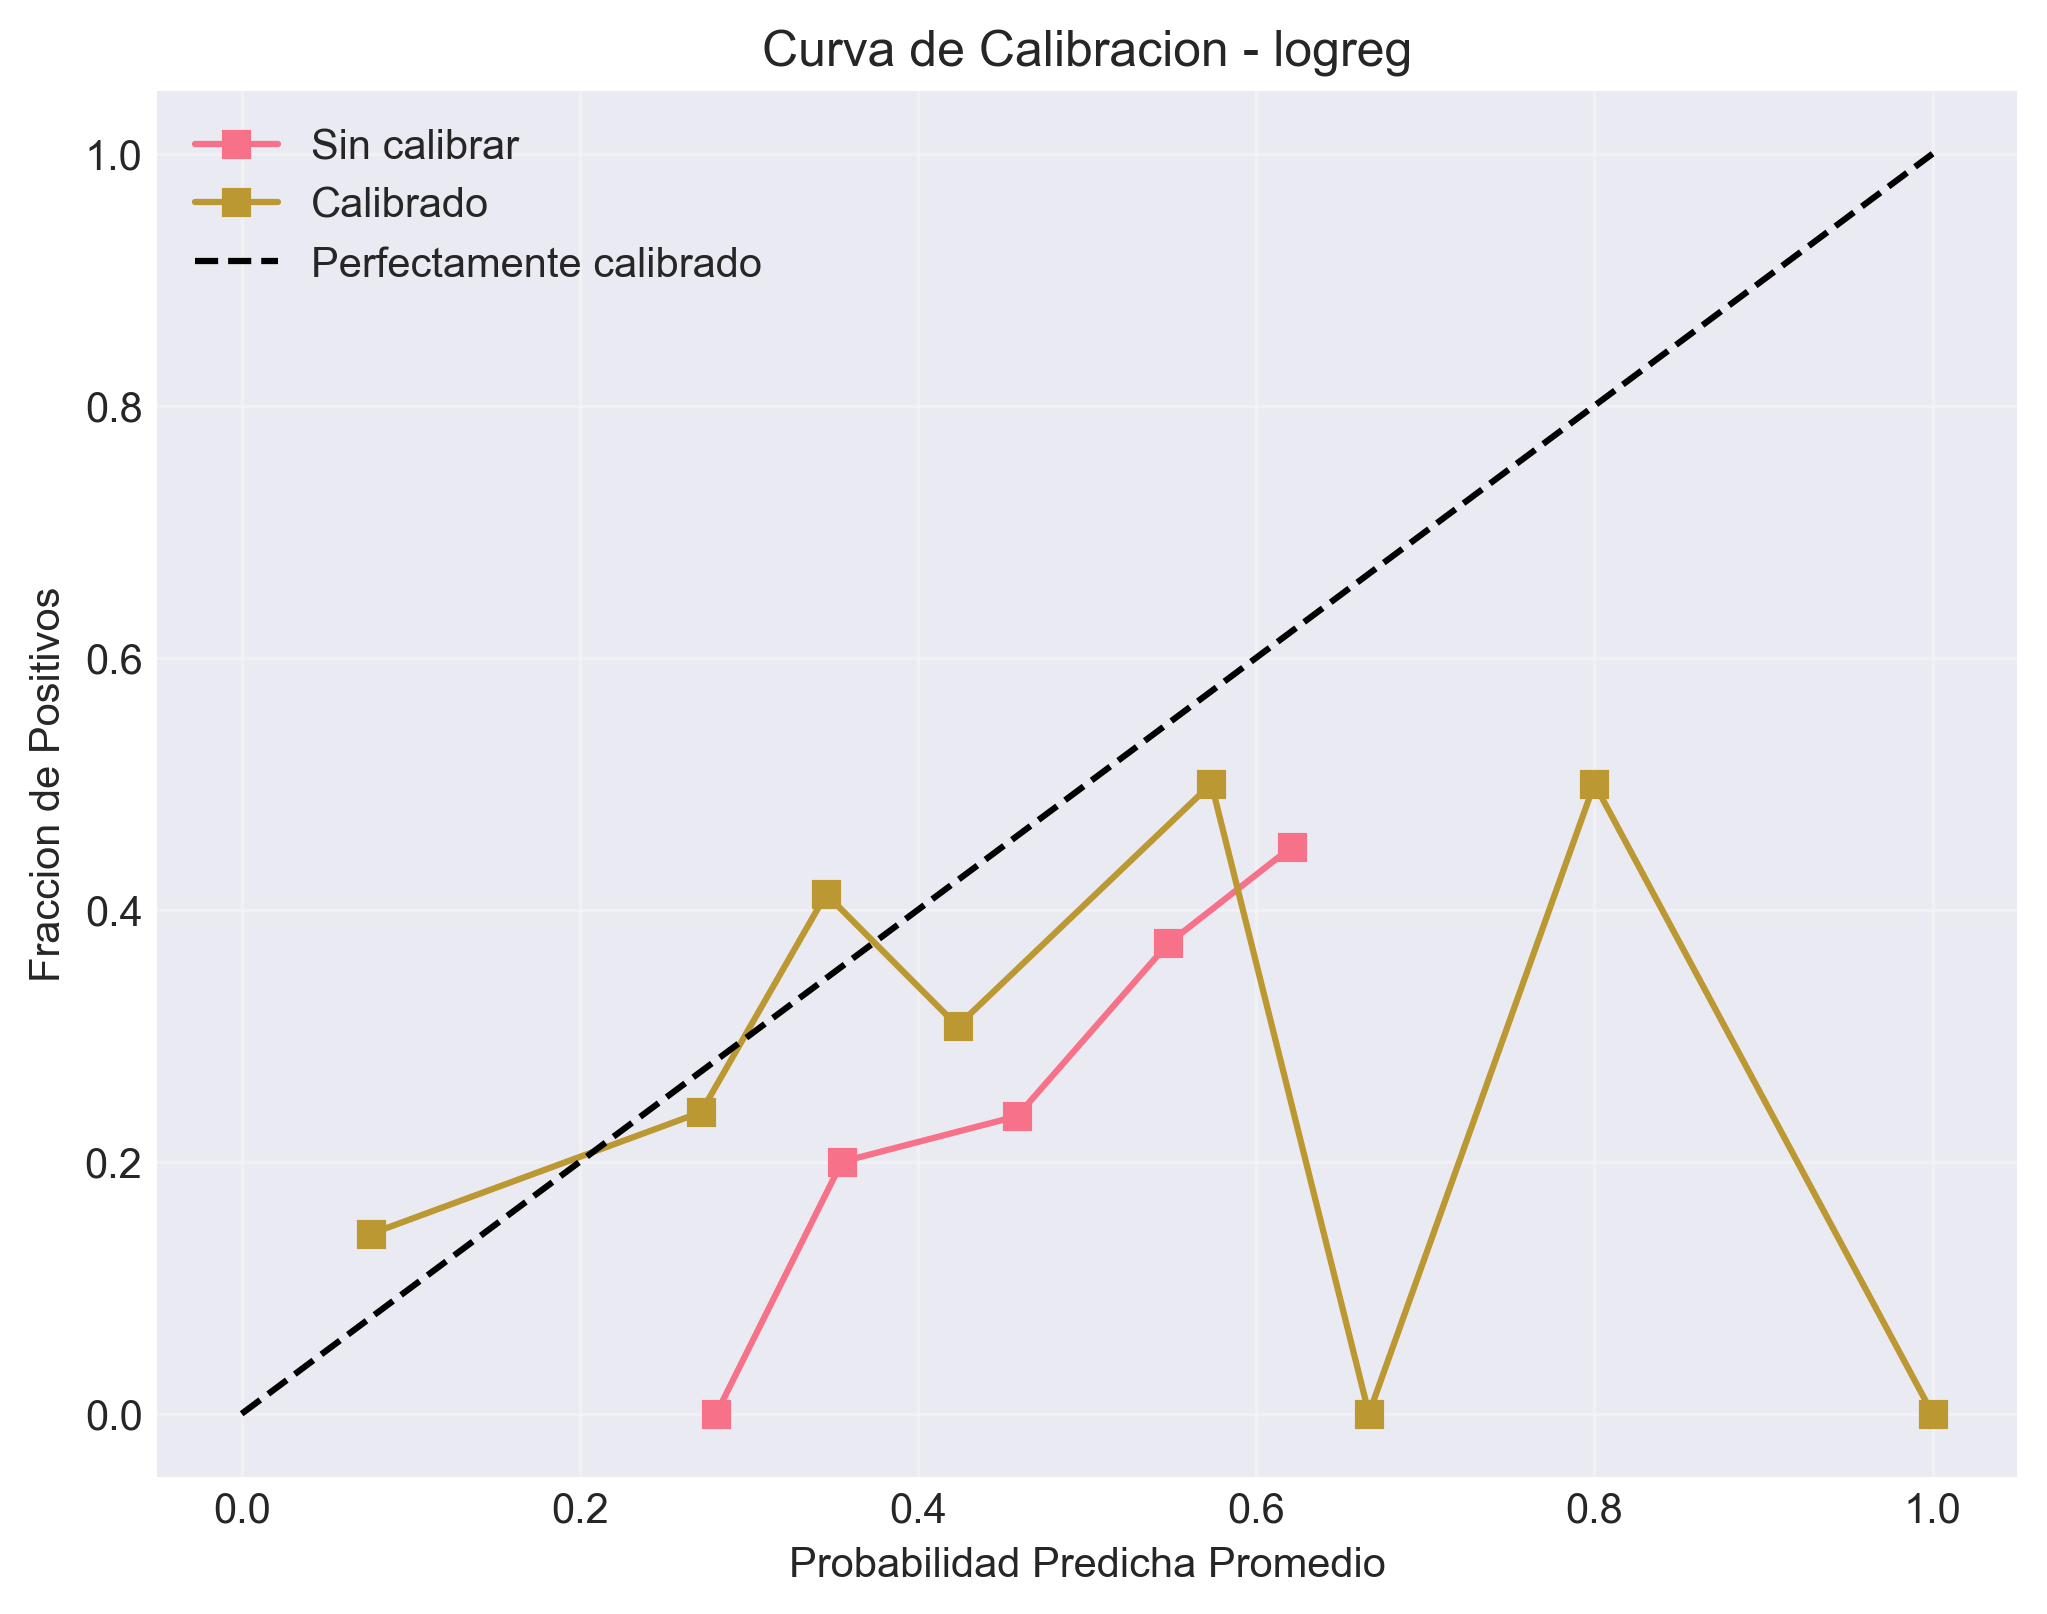


threshold_analysis.png


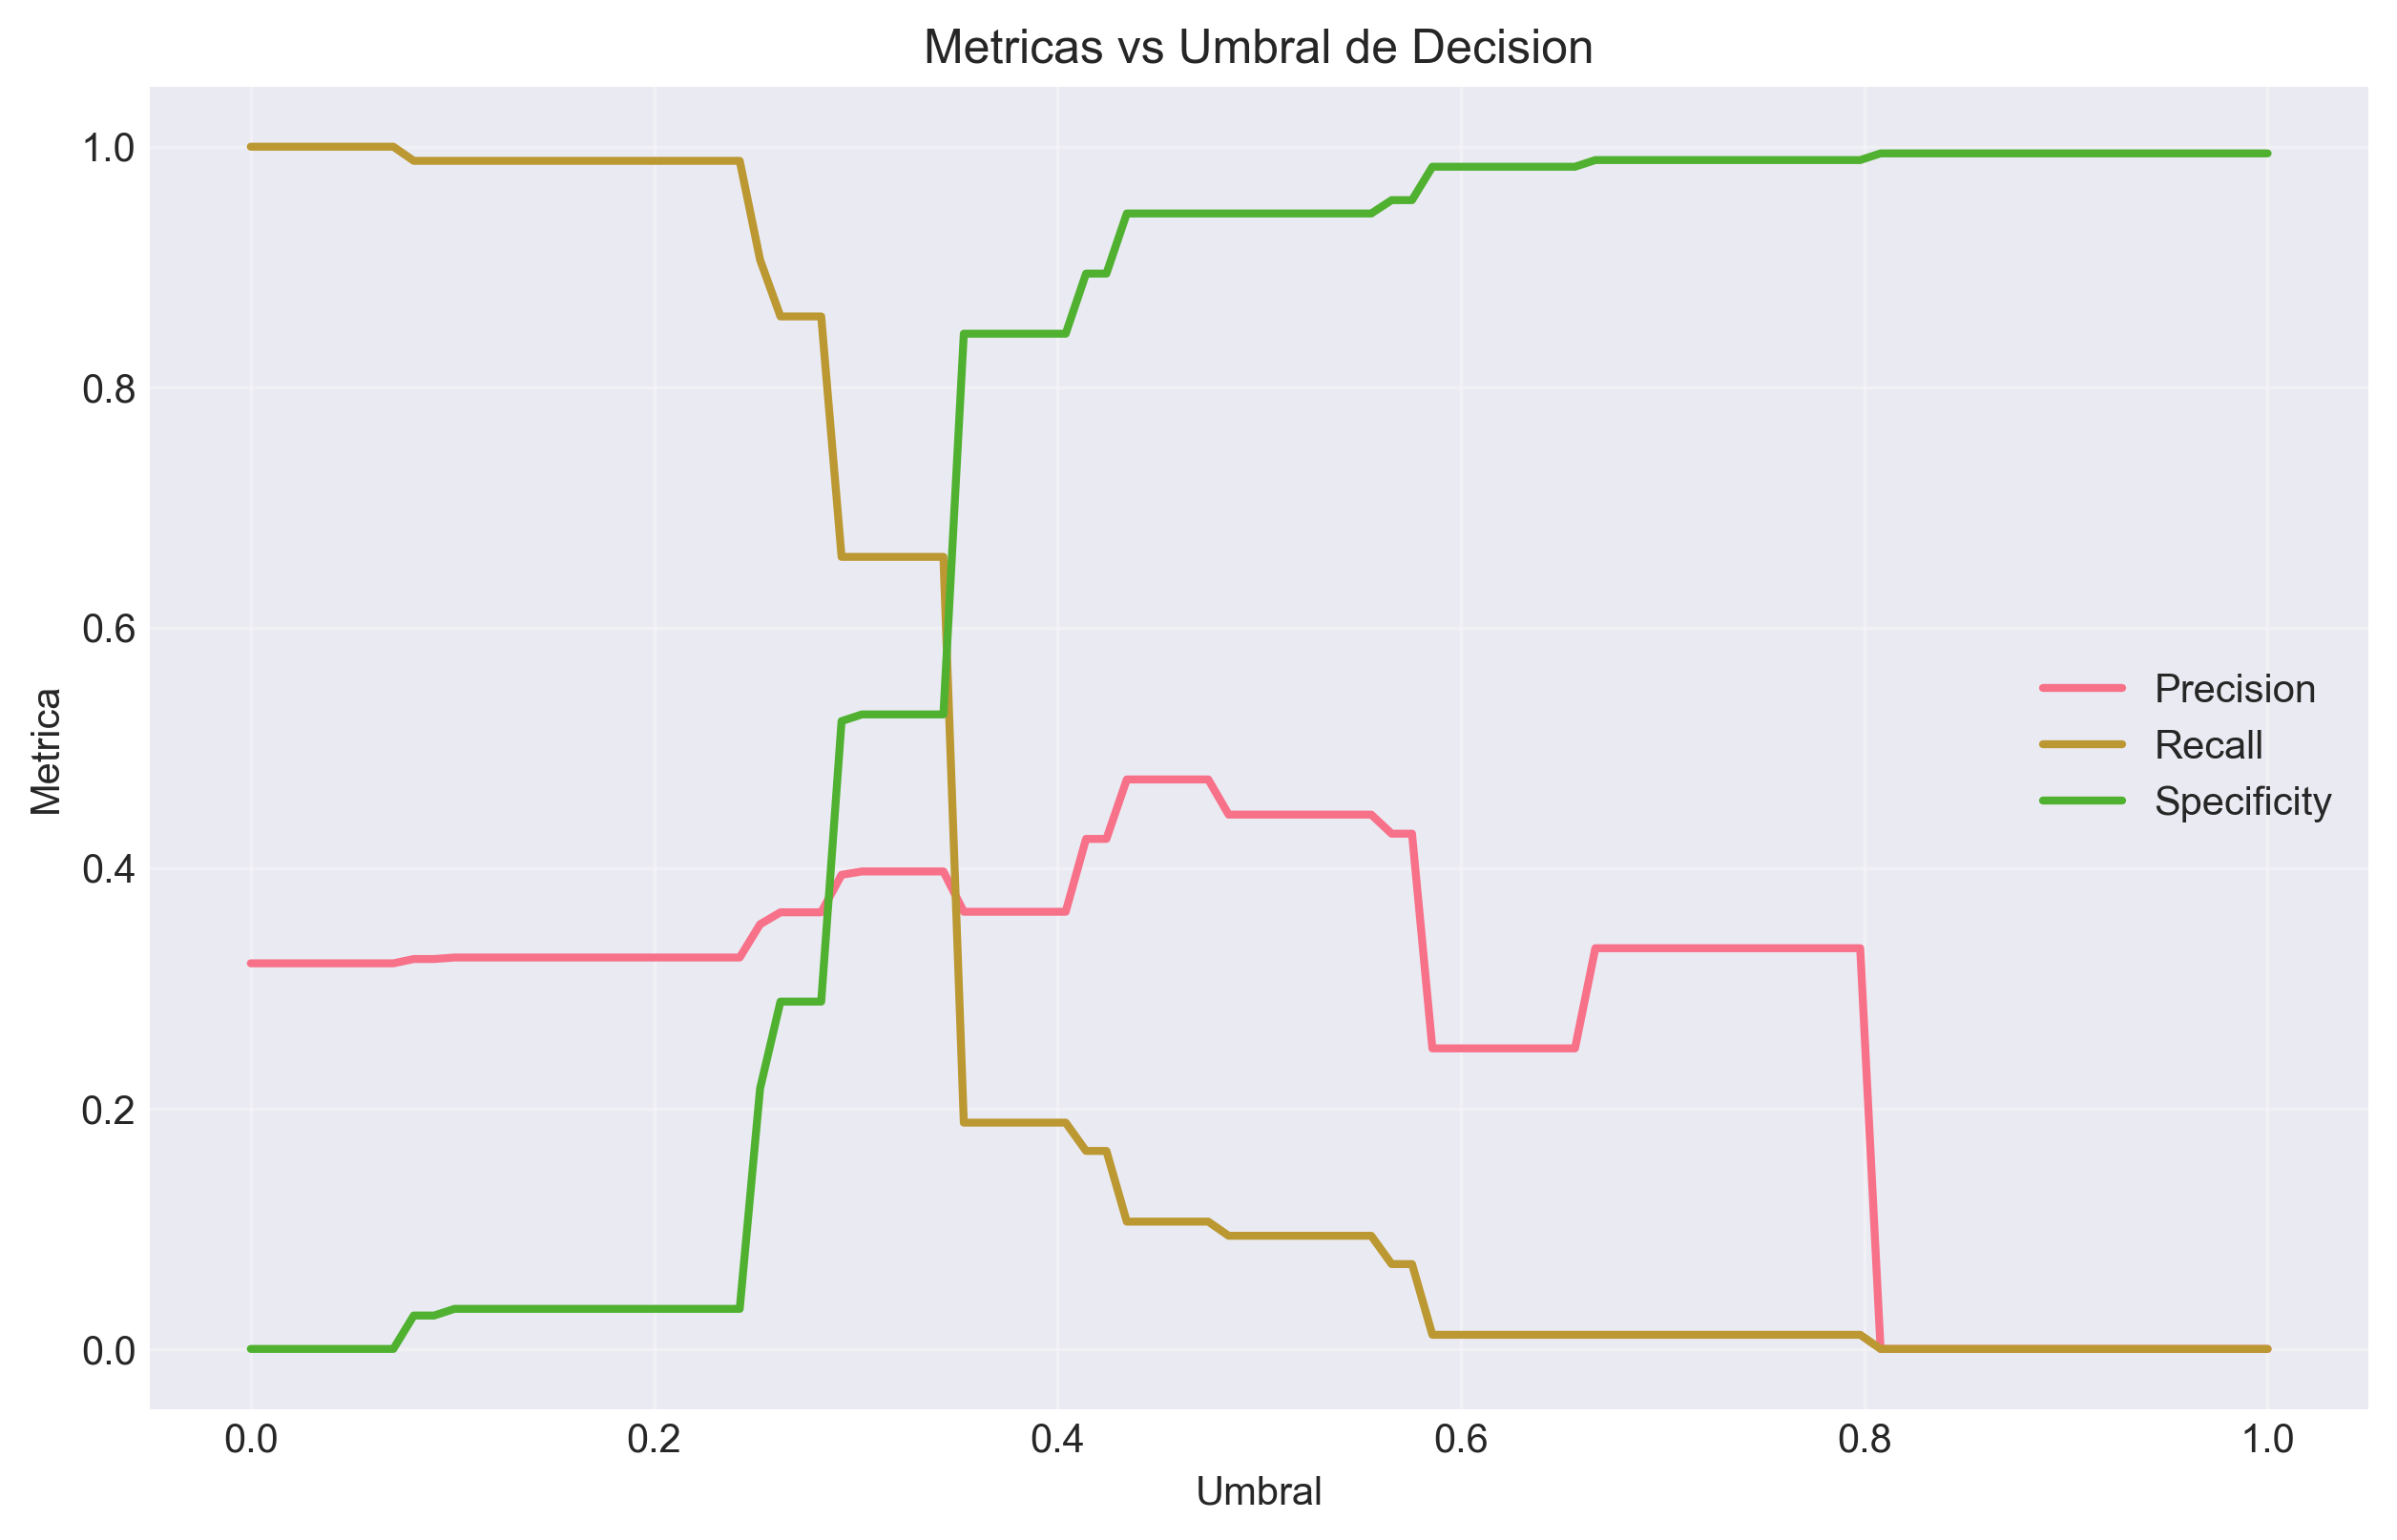

In [17]:
# Mostrar visualizaciones
from IPython.display import Image, display

viz_files = [
    'roc_curve.png',
    'precision_recall_curve.png',
    'confusion_matrix.png',
    'calibration_curve.png',
    'threshold_analysis.png'
]

for viz_file in viz_files:
    path = os.path.join(OUTPUT_DIR, viz_file)
    if os.path.exists(path):
        print(f"\n{viz_file}")
        display(Image(filename=path))

## 8. Importancia de Features

In [22]:
# Calcular importancia de features
pipeline.compute_feature_importance()


IMPORTANCIA DE FEATURES
Calculando permutation importance...
Permutation importance guardado en: ../reports/shock_output/explain/permutation_importance.csv
Grafico de importancia guardado en: ../reports/shock_output/feature_importance.png


Top 10 Features mas Importantes:
                 feature  importance_mean  importance_std
0                   EDAD         0.069937        0.031912
1   ENFERMEDAD_CORONARIA         0.006164        0.003834
2        INMUNOSUPRESION         0.000000        0.000000
3          CANCER_ACTIVO         0.000000        0.000000
4    ENF_CEREBROVASCULAR         0.000000        0.000000
5                   ASMA         0.000000        0.000000
6                   EPOC         0.000000        0.000000
7  HIPERTENSION_PULMONAR         0.000000        0.000000
8               OBESIDAD         0.000000        0.000000
9                    ERC         0.000000        0.000000


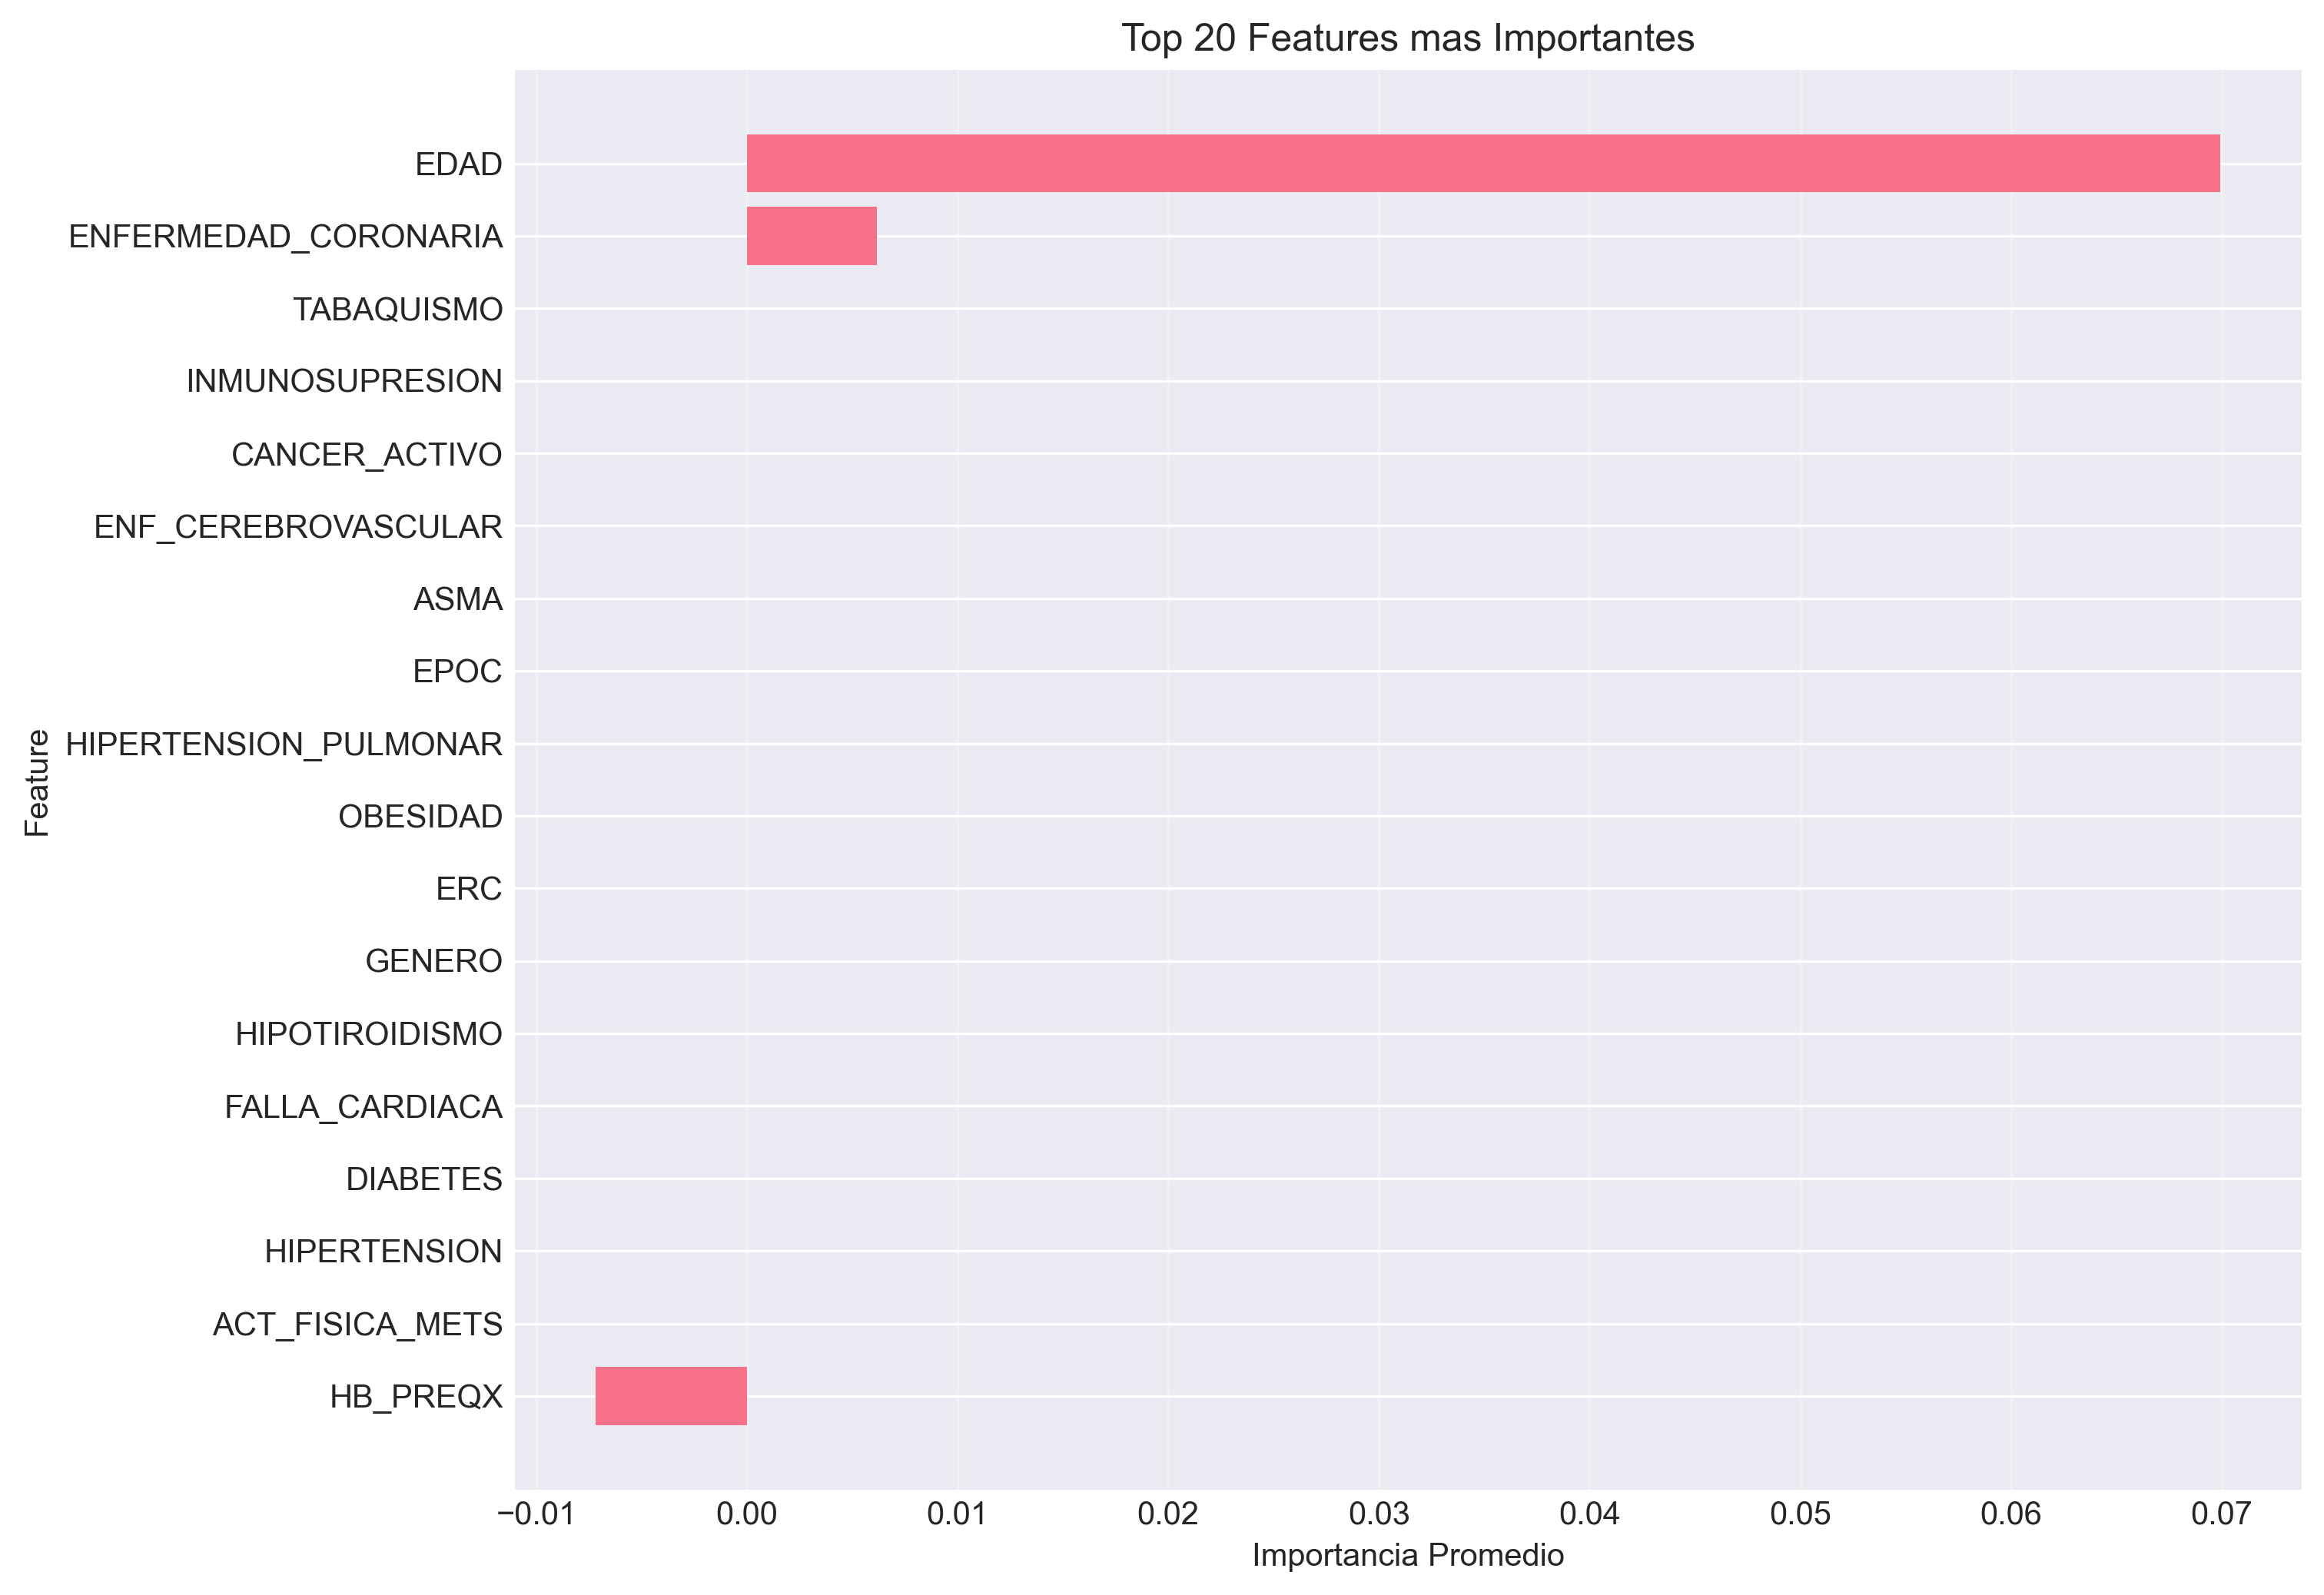

In [23]:
# Mostrar importancia
importance_path = os.path.join(OUTPUT_DIR, 'explain', 'permutation_importance.csv')
if os.path.exists(importance_path):
    importance_df = pd.read_csv(importance_path)
    print("Top 10 Features mas Importantes:")
    print(importance_df.head(10))
    
    # Visualizar
    feature_viz_path = os.path.join(OUTPUT_DIR, 'feature_importance.png')
    if os.path.exists(feature_viz_path):
        display(Image(filename=feature_viz_path))

## 9. Guardar Artefactos

In [20]:
# Guardar modelo y metadata
pipeline.save_artifacts()


GUARDADO DE ARTEFACTOS
Modelo guardado en: models/shock_logreg.joblib
Metadata guardada en: ../reports/shock_output/model_metadata.json


## 10. Resumen Final

In [21]:
# Cargar metadata
from src.utils.helpers import load_json

metadata_path = os.path.join(OUTPUT_DIR, 'artifact_metadata.json')
metadata = load_json(metadata_path)

print("="*60)
print("RESUMEN DEL MODELO FINAL")
print("="*60)
print(f"\nModelo: {metadata['model_name']}")
print(f"Timestamp: {metadata['timestamp']}")
print(f"\nMejores Parametros:")
for k, v in metadata['best_params'].items():
    print(f"  {k}: {v}")
print(f"\nMetricas en Test:")
for k, v in metadata['test_metrics'].items():
    print(f"  {k}: {v:.4f}")
print(f"\nMetricas Calibradas:")
for k, v in metadata['calibrated_metrics'].items():
    if v is not None:
        print(f"  {k}: {v:.4f}")
print(f"\nUmbral Optimizado:")
for k, v in metadata['tuned_threshold'].items():
    print(f"  {k}: {v:.4f}")
print(f"\nNotas: {metadata['notes']}")
print("="*60)

FileNotFoundError: [Errno 2] No such file or directory: '../reports/shock_output/artifact_metadata.json'

## 11. Uso del Modelo para Predicciones

Ejemplo de como cargar y usar el modelo entrenado.

In [ ]:
import joblib

# Cargar artefacto
artifact_path = os.path.join(OUTPUT_DIR, f"artifact_{pipeline.best_model_name}.joblib")
artifact = joblib.load(artifact_path)

model_pipeline = artifact['pipeline']
calibrator = artifact['calibrator']
model_metadata = artifact['metadata']

print("Modelo cargado exitosamente")
print(f"Modelo: {model_metadata['model_name']}")

In [ ]:
# Hacer predicciones en datos de test
X_test_sample = pipeline.X_test.head(10)

# Predicciones sin calibrar
proba_uncalibrated = model_pipeline.predict_proba(X_test_sample)[:, 1]

# Predicciones calibradas
X_test_trans = model_pipeline.named_steps['pre'].transform(X_test_sample)
proba_calibrated_sample = calibrator.predict_proba(X_test_trans)[:, 1]

# Usar umbral optimizado
threshold = model_metadata['tuned_threshold']['th']
predictions = (proba_calibrated_sample >= threshold).astype(int)

# Mostrar resultados
results_df = pd.DataFrame({
    'Probabilidad_sin_calibrar': proba_uncalibrated,
    'Probabilidad_calibrada': proba_calibrated_sample,
    'Prediccion': predictions
}, index=X_test_sample.index)

print(f"\nPredicciones usando umbral optimizado: {threshold:.4f}")
results_df